In [2]:
import numpy as np
import scipy.linalg as LA
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression


散佈圖畫法1

In [ ]:
# 1. load data
data_dir = 'Data/'
D = np.loadtxt(data_dir + 'la_1.txt', comments='%')
# 2. Scatter plot
# −−− define attributes for the scatter plot
s = 30 # define the size of markers
# define the colors of markers according to group value 0, 1
# colors = D[:,2]
# colors = [’red’ if i == 0 else ’blue’ for i in D[:,2]]
colors = [[1,0,0] if i == 0 else [0,0,1] for i in D[:,2]]
plt.scatter(D[:, 0], D[:, 1], c = colors, s = s, \
marker = 'o', alpha = 0.5)
plt.grid(True)

散佈圖畫法2

In [ ]:
# 1. 匯入資料
data_dir = 'Data/'
D = np.loadtxt(data_dir + 'la_1.txt', comments='%')
# 2. 繪製散佈圖
Idx = (D[:,2]==0)
plt.plot(D[Idx, 0], D[Idx, 1], 'ro',\
alpha = 0.5, label = 'Group A')
Idx = (D[:,2]==1)
plt.plot(D[Idx,0], D[Idx,1],'bo', \
alpha = 0.5, label = 'Group B')
plt.legend(), plt.grid(True)
plt.xlabel('$X_1$'), plt.ylabel('$X_2$')
# −−− define attributes for the scatter plot
# s = 30 # define the size of markers
# define the colors of markers according to group value 0, 1
# colors = D[:,2]
# colors = [’red’ if i == 0 else ’blue’ for i in D[:,2]]
# colors = [[1,0,0] if i == 0 else [0,0,1] for i in D[:,2]]
# plt.scatter(D[:, 0], D[:, 1], c = colors, s = s, \
# marker = 'o', alpha = 0.5)


簡單線性迴歸(1變數) $x2 = f(x1) = (0.5 − β_0 − β_1x_1)/β_2$ (係數用手算)

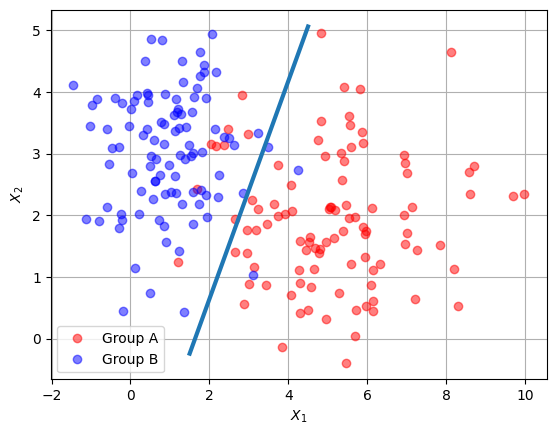

In [3]:
# 1. 匯入資料
data_dir = 'Data/'
D = np.loadtxt(data_dir + 'la_1.txt', comments='%')
# -----------------------------------------------------------------
# 2. 繪製散佈圖
Idx = (D[:,2]==0)
plt.plot(D[Idx, 0], D[Idx, 1], 'ro',\
alpha = 0.5, label = 'Group A')
Idx = (D[:,2]==1)
plt.plot(D[Idx,0], D[Idx,1],'bo', \
alpha = 0.5, label = 'Group B')
plt.legend(), plt.grid(True)
plt.xlabel('$X_1$'), plt.ylabel('$X_2$')
# -----------------------------------------------------------------
#簡單線性迴歸
n = len(D[:, 0])
X = np.hstack((np.ones((n, 1)), D[:, 0:2]))
y = D[:, 2]
b = LA.pinv(X) @ y
# Draw a linear regression line
x = np.array([1.5, 4.5])
y = -(b[0] - 0.5 + b[1] * x) / b[2]
plt.plot(x, y, lw=3)
plt.show()


簡單線性迴歸(1變數) $x2 = f(x1) = (0.5 − β_0 − β_1x_1)/β_2$ (係數用sklearn算)

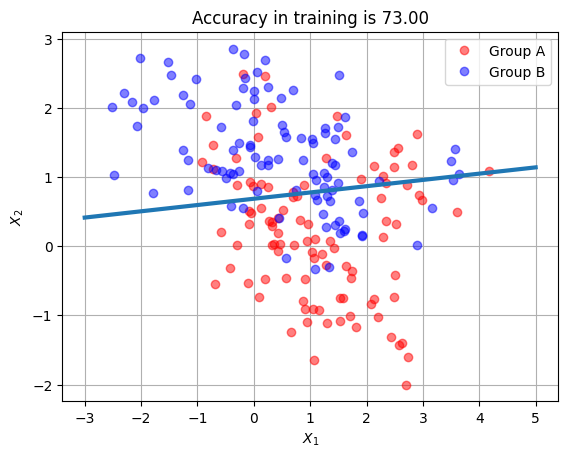

In [2]:
# 1. 匯入資料
data_dir = 'Data/'
D = np.loadtxt(data_dir + 'la_3.txt', comments='%')
# -----------------------------------------------------------------
# 2. 繪製散佈圖
Idx = (D[:,2]==0)
plt.plot(D[Idx, 0], D[Idx, 1], 'ro',\
alpha = 0.5, label = 'Group A')
Idx = (D[:,2]==1)
plt.plot(D[Idx,0], D[Idx,1],'bo', \
alpha = 0.5, label = 'Group B')
plt.legend(), plt.grid(True)
plt.xlabel('$X_1$'), plt.ylabel('$X_2$')
# -----------------------------------------------------------------
# Linear Regression by sklearn
n = len(D[:, 0])
X = D[:, 0:2]
y = D[:, 2]
Mdl = LinearRegression()# 建立新的 linear regression model
Mdl.fit(X, y) # 進行估計 （ 配適 ）
# R2 = Mdl.score(X, y) # R−square
intrcp = Mdl.intercept_ # 估計結果 ：beta0
coeffs = Mdl.coef_ # # 估計結果 ：beta1, beta2, ...
# Draw a regression line
x = np.array([-3, 5])
f = -(intrcp - 0.5 + coeffs[0] * x) / coeffs[1]
plt.plot(x, f, lw=3)
# -----------------------------------------------------------------
# Calculate testing error
y_hat = Mdl.predict(X) # 預 測 或 計 算 擬 合 值
y_pre = [1 if i > 0.5 else 0 for i in y_hat] # 群組判讀
plt.title('Accuracy in training is {:.2f}'.format( \
100 * np.mean(y_pre == y)))
plt.xlabel('$X_1$'), plt.ylabel('$X_2$')
plt.show()



加廣型迴歸 $f(X1, X2) = β_0 - 0.5 + β_1X_1 + β_2X_2 + β_3X_1X_2 + β_4X^2_1 + β_5X_2^2$

-7.5 5 0.0 3.0


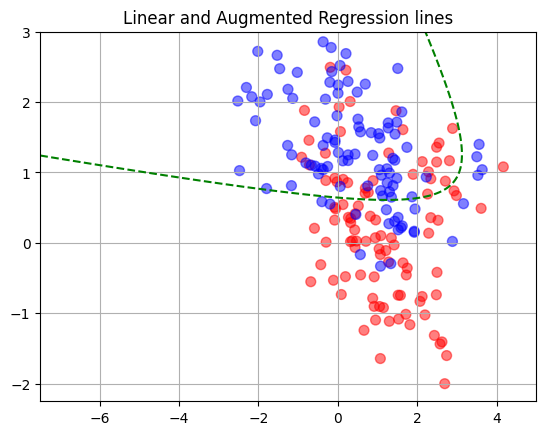

In [4]:
#匯入資料
data_dir = 'Data/'
D = np.loadtxt(data_dir + 'la_3.txt', comments='%')
# -----------------------------------------------------------------
#繪製散佈圖
area = 50+D[:, 2]
colors = ["red" if i == 0 else "blue" for i in D[:, 2]]
plt.scatter(D[:, 0], D[:, 1], c=colors, s=area, alpha=0.5, marker="o")
plt.grid(True)
# -----------------------------------------------------------------
#加廣型迴歸
n = len(D[:, 0])
x1 = D[:, 0:1]  # n x 1 vector
x2 = D[:, 1:2]
X = np.hstack((np.ones((n, 1)),
               x1, x2, x1 * x2, x1 ** 2, x2 ** 2))
y = D[:, 2:3]
b = LA.pinv(X) @ y  # pseudo inverse
f = (
    lambda x: b[0]
    + b[1] * x[0]
    + b[2] * x[1]
    + b[3] * x[0] * x[1]
    + b[4] * x[0] ** 2
    + b[5] * x[1] ** 2)
x = np.array([-3, 5])
x_range_min = x.min()-4.5
x_range_max = x.max()
y_range_min = y.min()
y_range_max = y.max()+2
print(x_range_min, x_range_max, y_range_min, y_range_max)
xx = np.linspace(x_range_min, x_range_max, n)
yy = np.linspace(y_range_min, y_range_max, n)
X, Y = np.meshgrid(xx, yy)
Z = f([X, Y])
contours = plt.contour(
    X, Y, Z, levels=[0.5], colors='g', linestyles='--')
plt.title('Linear and Augmented Regression lines')
plt.show()


2個迴歸放一起

C:\Users\jameslin\AppData\Local\Temp\ipykernel_18404\2614687183.py:45: RuntimeWarning: invalid value encountered in sqrt
  f1 = ( (-b_) + np.sqrt( (b_**2)- (4*a_*c_) ) )/(2*a_)
C:\Users\jameslin\AppData\Local\Temp\ipykernel_18404\2614687183.py:51: RuntimeWarning: invalid value encountered in sqrt
  f2 = ( (-b_) - np.sqrt( (b_**2)- (4*a_*c_) ) )/(2*a_)


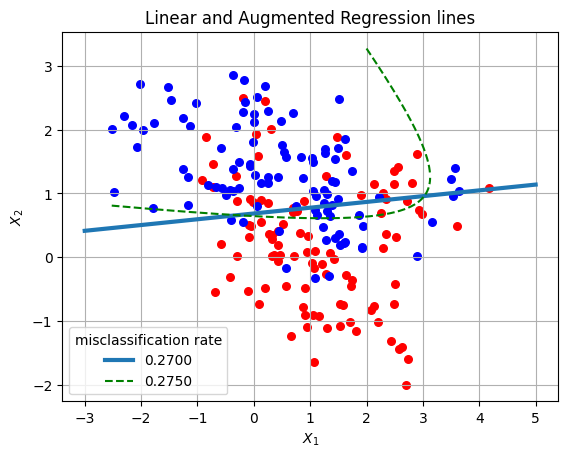

In [5]:
import numpy as np
import scipy.linalg as LA
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

data_dir = 'Data/'
D = np.loadtxt(data_dir + 'la_3.txt', comments='%')

marks_size = 30
class_ = [0, 1]
class_num = len(class_)
colors = ['r', 'b']
#label = ['Group {}'.format(i) for i in range(1, class_num+1)]
idx = np.array([(D[:, 2] == c) for c in class_])
for i in range(class_num):
    plt.scatter(D[idx[i], 0], D[idx[i], 1], marker = 'o', s = marks_size,
    c = colors[i])


n = len(D)
X = np.hstack((np.ones((n, 1)), D[:, 0:2]))
y = D[:, 2]
b = LA.inv(X.T @ X) @ X.T @ y
x = np.array([-3, 5])
f = -(b[0] -0.5 + b[1] * x) / b[2]
y_hat = X @ b
y_pre = y_pre = np.array([1 if i > 0.5 else 0 for i in y_hat])
plt.plot(x, f, lw=3, label = '{:.4f}'.format(np.mean(y != y_pre)))


x0 = np.ones((n ,1))
x1 = D[:, 0:1]
x2 = D[:, 1:2]
x3 = x1 * x2
x4 = x1 * x1
x5 = x2 * x2
X = np.hstack( ( x0, x1, x2, x3, x4, x5) )
y = D[:, 2]
#b = LA.inv(X.T @ X) @ X.T @ y
b = LA.pinv(X) @ y
xx1 = np.linspace(x1.min(), x1.max(), 5000)
a_ = b[5]
b_ = xx1*b[3] + b[2]
c_ = -0.5 + xx1*b[1] + (xx1**2)*b[4] +b[0] 
f1 = ( (-b_) + np.sqrt( (b_**2)- (4*a_*c_) ) )/(2*a_)

xx11 = np.linspace(2, x1.max(), 5000)
a_ = b[5]
b_ = xx11*b[3] + b[2]
c_ = -0.5 + xx11*b[1] + (xx11**2)*b[4] +b[0] 
f2 = ( (-b_) - np.sqrt( (b_**2)- (4*a_*c_) ) )/(2*a_)
y_hat = X @ b
y_pre = np.array([1 if i > 0.5 else 0 for i in y_hat])
xx = np.hstack((xx1, xx11))
f   = np.hstack((f1, f2))
plt.plot(xx, f, c = 'g', linestyle= '--', label = '{:.4f}'.format(np.mean(y != y_pre)))
plt.title('Linear and Augmented Regression lines')
plt.legend(title = 'misclassification rate')
plt.grid(True)
plt.xlabel('$X_1$')
plt.ylabel('$X_2$')
plt.show()

自己生成資料+2個迴歸學習器

-7.5 6 -4.0 6.0


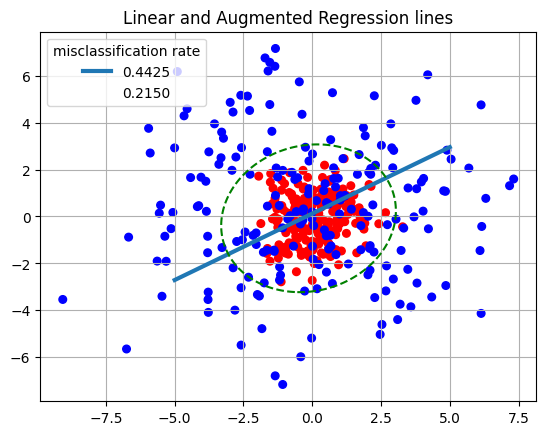

In [197]:
import numpy as np
import scipy.linalg as LA
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from scipy.stats import multivariate_normal
# -----------------------------------------------------------------
# 生成資料
n1, n2 = 200, 200
m1, m2 = np.array([0, 0]), np.array([0, 0])
Cov1 = np.array([[1, 0], [0, 1]])
Cov2 = np.array([[10, 0], [0,10]])
mvn1 = multivariate_normal(mean = m1, cov = Cov1)
mvn2 = multivariate_normal(mean = m2, cov = Cov2)
A, B = mvn1.rvs(n1), mvn2.rvs(n2)
X = np.vstack((A, B))
y = np.hstack((np.zeros(n1), np.ones(n2)))
np.savetxt('demo_data.txt', np.c_[X, y],\
fmt = '%.4f %.4f %d', header = 'X1 X2 y')
colors = ['red' if i == 0 else 'blue' for i in y]
plt.scatter(X[:, 0], X[:, 1], \
c=colors, s=30, marker='o')
plt.grid(True)
# -----------------------------------------------------------------
# 線性迴歸模型
n = n1+n2
X = np.hstack((np.ones((n, 1)), X[:, 0:2]))
b = LA.inv(X.T @ X) @ X.T @ y
x = np.array([-5,5])
f = -(b[0] -0.5 + b[1] * x) / b[2]
y_hat = X @ b
y_pre = np.array([1 if i > 0.5 else 0 for i in y_hat])
plt.plot(x, f, lw=3, label = '{:.4f}'.format(np.mean(y != y_pre)))
# -----------------------------------------------------------------
# 加廣型線性迴歸模型
# 變數整理
x0 = np.ones((n ,1))
x1 = X[:, 1:2]
x2 = X[:, 2:3]
X = np.hstack((np.ones((n, 1)),
               x1, x2, x1 * x2, x1 ** 2, x2 ** 2))
b = LA.pinv(X) @ y  # pseudo inverse
# -----------------------------------------------------------------
f = (
    lambda x: b[0]
    + b[1] * x[0]
    + b[2] * x[1]
    + b[3] * x[0] * x[1]
    + b[4] * x[0] ** 2
    + b[5] * x[1] ** 2)
x_range_min = x.min()-2.5
x_range_max = x.max()+1
y_range_min = y.min()-4
y_range_max = y.max()+5
print(x_range_min, x_range_max, y_range_min, y_range_max)
xx = np.linspace(x_range_min, x_range_max, n)
yy = np.linspace(y_range_min, y_range_max, n)
y_hat = X @ b
y_pre = np.array([1 if i > 0.5 else 0 for i in y_hat])
X, Y = np.meshgrid(xx, yy)
Z = f([X, Y])
# -----------------------------------------------------------------
# 繪製 augmented regression line
contours = plt.contour(X, Y, Z, levels = [0.5], colors='g', linestyles='--')
contours.collections[0].set_label('{:.4f}'.format(1 - np.mean(y_pre == y)))
plt.title('Linear and Augmented Regression lines')
plt.legend(title = 'misclassification rate')
plt.show()

羅吉斯迴歸

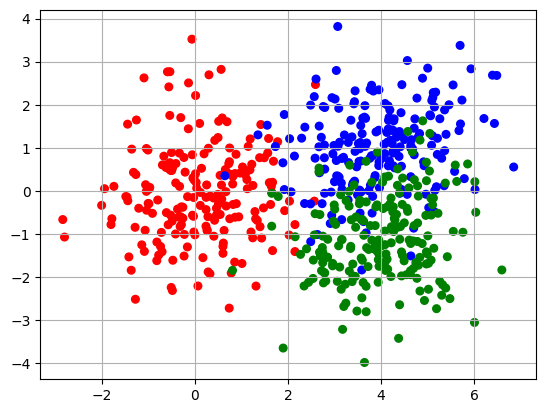

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import multivariate_normal
n1, n2,n3 = 200, 200,200 #2組 資 料 內 的 各 樣 本 數
m1, m2 ,m3= np.array([0, 0]), np.array([4, 1]),np.array([4, -1]) #2 維 normal的 中 心 點
Cov1 = np.array([[1, 0], [0, 1]])
Cov2 = np.array([[1, 0.2], [0.2, 1]])
Cov3 = np.array([[1, 0.2], [0.2, 1]])
mvn1 = multivariate_normal(mean = m1, cov = Cov1)
mvn2 = multivariate_normal(mean = m2, cov = Cov2)
mvn3 = multivariate_normal(mean = m3, cov = Cov3)
A, B,C = mvn1.rvs(n1), mvn2.rvs(n2), mvn3.rvs(n3)
X = np.vstack((A, B,C))
y = np.hstack((np.zeros(n1), np.ones(n2),2*np.ones(n3)))
np.savetxt('demo_data.txt', np.c_[X, y],\
fmt = '%.4f %.4f %d', header = 'X1 X2 X3 y')
colors = ['red' if i == 0 else 'blue' if i == 1 else 'green' for i in y]
plt.scatter(X[:, 0], X[:, 1],c=colors, s=30, marker='o')
plt.grid(True)
plt.show()